# CNNs: Teaching Your Network to See

In the previous demo, a Dense model managed only ~38% accuracy on CIFAR-10. It flattened every image into a 1D vector of 3,072 numbers — throwing away all spatial structure. A pixel in the top-left corner was just as "connected" to the output as its immediate neighbor.

Convolutional Neural Networks (CNNs) fix this. Instead of connecting every pixel to every neuron, a CNN slides small filters across the image, detecting local patterns — edges, textures, shapes — regardless of where they appear. This demo builds a CNN on the same CIFAR-10 data and shows the difference.

## Setup

In [1]:
%pip install -q -r requirements.txt

# GPU acceleration (platform-specific)
import platform
if platform.system() == "Darwin" and platform.machine() == "arm64":
    %pip install -q tensorflow-metal

%reset -f

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

REBUILD = False
NUM_CLASSES = 10
EPOCHS = 15
BATCH_SIZE = 64

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

%mkdir -p models

GPU acceleration: 1 device(s)
  /physical_device:GPU:0


## Load and Prepare CIFAR-10

Same preparation as Demo 2 — normalize, one-hot encode, split.

In [3]:
(X_train_raw, y_train_raw), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train_scaled = X_train_raw.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train_raw, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_cat, test_size=0.1, random_state=42
)

print(f"Train: {X_train_final.shape}, Val: {X_val.shape}, Test: {X_test_scaled.shape}")

Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


## Why CNNs? A Visual Intuition

A Dense layer sees this — a flat strip of 3,072 numbers with no spatial meaning:

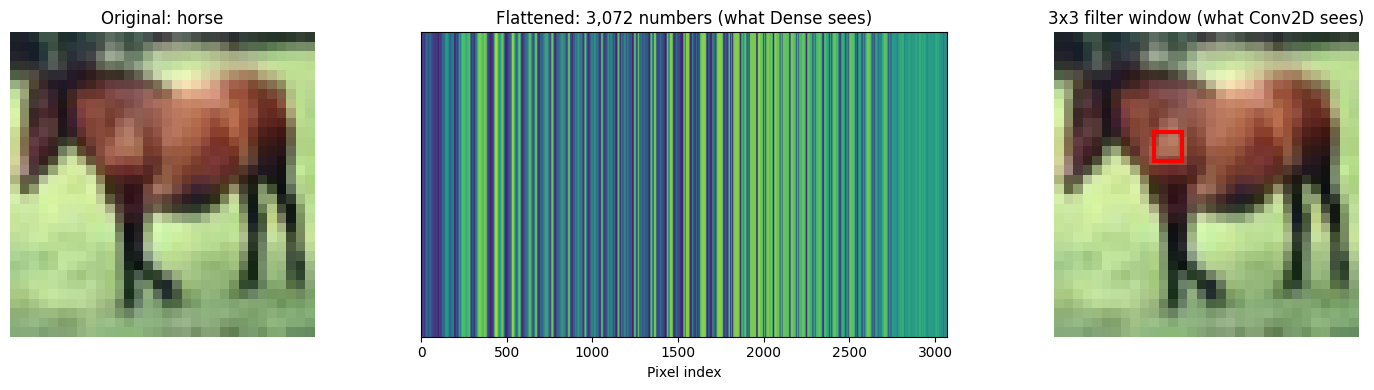

In [4]:
sample = X_train_scaled[7]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Original image
axes[0].imshow(sample)
axes[0].set_title(f'Original: {CLASS_NAMES[y_train_raw[7, 0]]}', fontsize=12)
axes[0].axis('off')

# Flattened representation (what Dense sees)
flat = sample.reshape(1, -1)
axes[1].imshow(flat, aspect='auto', cmap='viridis')
axes[1].set_title('Flattened: 3,072 numbers (what Dense sees)', fontsize=12)
axes[1].set_xlabel('Pixel index')
axes[1].set_yticks([])

# What a Conv2D filter sees — highlight a 3x3 patch
axes[2].imshow(sample)
rect = plt.Rectangle((10, 10), 3, 3, linewidth=3, edgecolor='red', facecolor='none')
axes[2].add_patch(rect)
axes[2].set_title('3x3 filter window (what Conv2D sees)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

A Conv2D filter slides that small red window across the entire image. At each position, it multiplies its learned weights against the local pixels to detect a specific pattern — a horizontal edge, a color gradient, a texture. The same filter detects the same pattern anywhere in the image.

## Build the CNN

Three convolutional blocks extract spatial features, then Dense layers classify them. Compare the parameter count to the Dense model from Demo 2.

In [5]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model_cnn = Sequential([
    Input(shape=(32, 32, 3)),

    # Block 1: detect simple patterns (edges, textures)
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Block 2: combine simple patterns into complex features
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Block 3: higher-level features
    Conv2D(64, (3, 3), activation='relu'),

    # Classification head
    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

The Conv2D layers have far fewer parameters than the Dense(256) layer in Demo 2, yet they capture spatial relationships that Dense layers cannot.

## Train with Callbacks

Two callbacks automate training management:

- **ModelCheckpoint** saves the best model weights during training
- **EarlyStopping** halts training when validation loss stops improving, then restores the best weights

In [6]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

CNN_PATH = 'models/cifar10_cnn.keras'
CNN_HIST = CNN_PATH + '.history.pkl'

if not REBUILD:
    if not os.path.exists(CNN_PATH):
        !curl -fSL -o {CNN_PATH} 'https://data.badmath.org/cifar10_cnn.keras' 2>/dev/null
    if not os.path.exists(CNN_HIST):
        !curl -fSL -o {CNN_HIST} 'https://data.badmath.org/cifar10_cnn.keras.history.pkl' 2>/dev/null

if REBUILD or not os.path.exists(CNN_PATH):
    callbacks = [
        ModelCheckpoint(
            CNN_PATH,
            save_best_only=True,
            monitor='val_accuracy'
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]

    history_cnn = model_cnn.fit(
        X_train_final, y_train_final,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=callbacks
    )
    model_cnn.save(CNN_PATH)
    with open(CNN_HIST, 'wb') as f:
        pickle.dump(history_cnn.history, f)
    hist_cnn = history_cnn.history
else:
    model_cnn = keras.models.load_model(CNN_PATH)
    with open(CNN_HIST, 'rb') as f:
        hist_cnn = pickle.load(f)

print(f"Training complete — {len(hist_cnn['loss'])} epochs")

Training complete — 8 epochs


## Training Curves

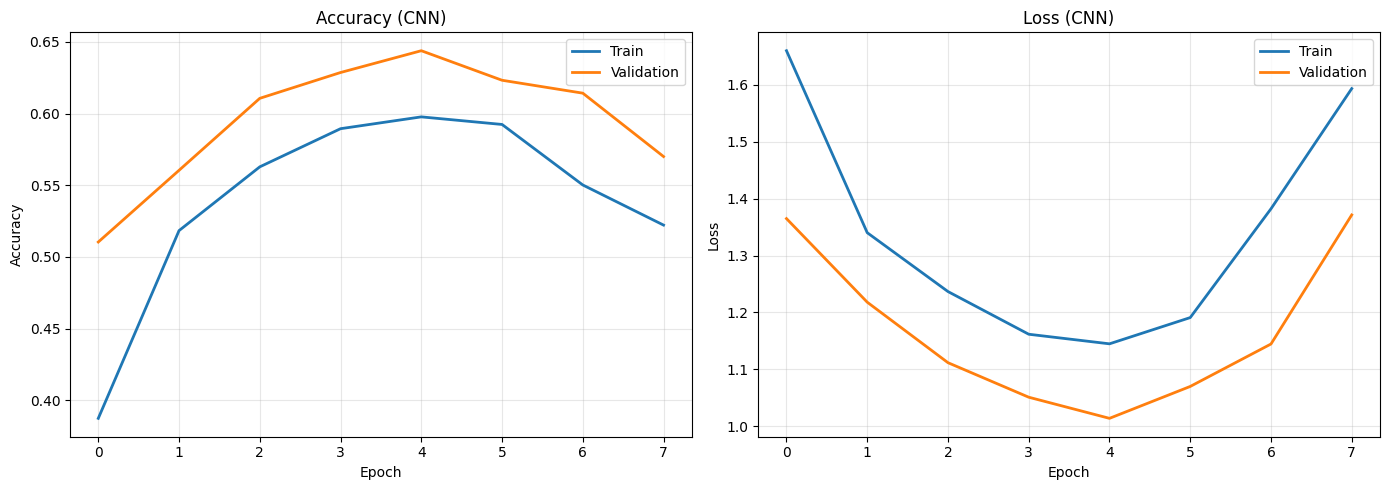

In [7]:
def plot_training_curves(history, title=''):
    """Plot accuracy and loss curves for training and validation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['accuracy'], label='Train', linewidth=2)
    ax1.plot(history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_title(f'Accuracy {title}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['loss'], label='Train', linewidth=2)
    ax2.plot(history['val_loss'], label='Validation', linewidth=2)
    ax2.set_title(f'Loss {title}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(hist_cnn, '(CNN)')

## Evaluate and Compare with Dense

In [8]:
cnn_loss, cnn_acc = model_cnn.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"CNN test accuracy:   {cnn_acc:.2%}")
print(f"Dense test accuracy: ~38%  (from Demo 2)")

CNN test accuracy:   63.57%
Dense test accuracy: ~38%  (from Demo 2)


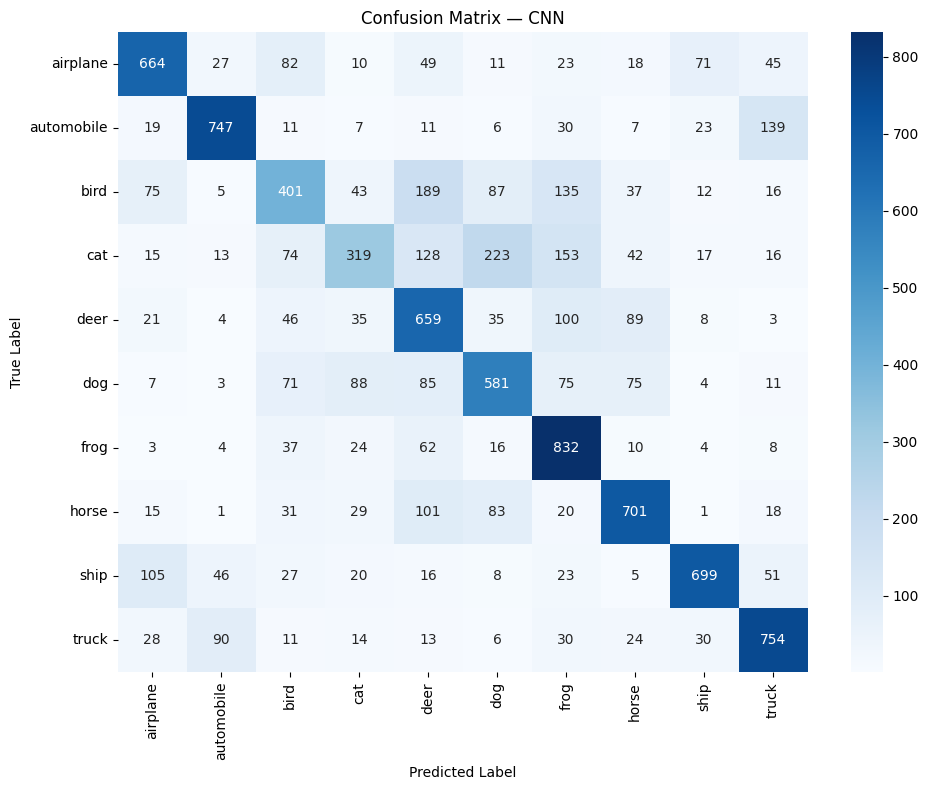

In [9]:
# Confusion matrix
y_pred = model_cnn.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test.flatten()

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

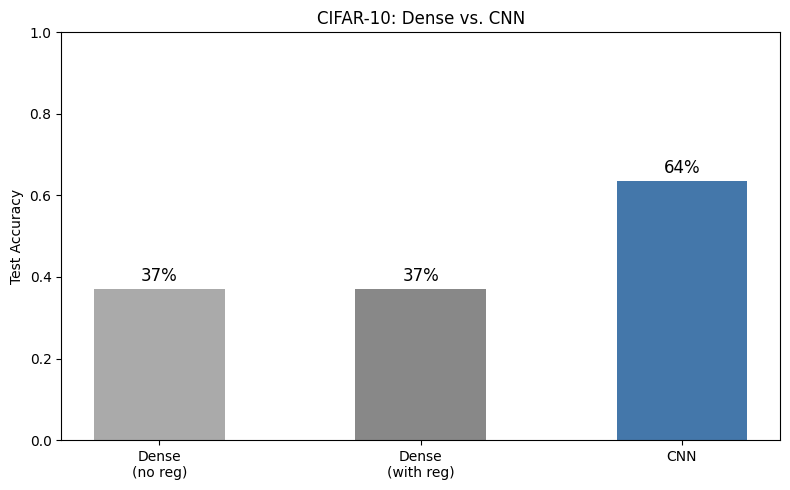

In [10]:
# Side-by-side accuracy comparison
models = ['Dense\n(no reg)', 'Dense\n(with reg)', 'CNN']
accs = [0.37, 0.37, cnn_acc]  # Dense values approximate from Demo 2
colors = ['#aaaaaa', '#888888', '#4477AA']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=colors, width=0.5)
plt.ylabel('Test Accuracy')
plt.title('CIFAR-10: Dense vs. CNN')
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.0%}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

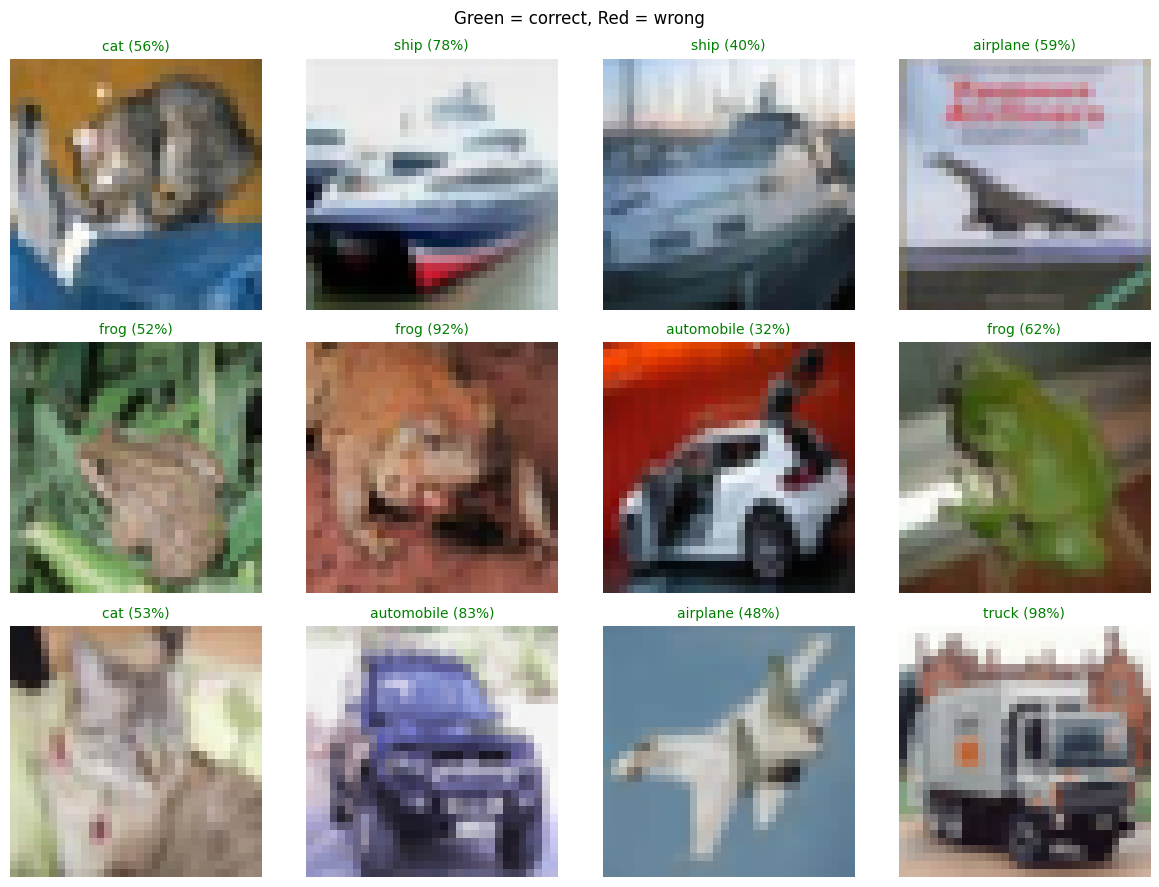

In [11]:
# Sample predictions
def plot_predictions(model, X, y_true, class_names, n=12, cols=4):
    """Show predictions with green (correct) / red (wrong) labels."""
    preds = model.predict(X[:n], verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = y_true[:n].flatten()

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(X[i])
        correct = pred_classes[i] == true_classes[i]
        color = 'green' if correct else 'red'
        confidence = preds[i][pred_classes[i]]
        ax.set_title(f"{class_names[pred_classes[i]]} ({confidence:.0%})",
                     color=color, fontsize=10)
        ax.axis('off')
    plt.suptitle('Green = correct, Red = wrong', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_predictions(model_cnn, X_test_scaled, y_test, CLASS_NAMES)

## Saving and Loading Models

Training a model can take minutes to hours. Save it so you don't have to retrain every time.

In [12]:
# Save the entire model (architecture + weights + optimizer state)
model_cnn.save('models/my_cifar10_cnn.keras')

# Load it back
from keras.models import load_model
loaded_model = load_model('models/my_cifar10_cnn.keras')

# Verify it works
loaded_loss, loaded_acc = loaded_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Loaded model accuracy: {loaded_acc:.2%}")
print(f"Matches original:      {abs(loaded_acc - cnn_acc) < 1e-6}")

Loaded model accuracy: 63.57%
Matches original:      True


The `.keras` format saves everything: architecture, weights, optimizer state. You can resume training or deploy for predictions.

## What Did the CNN Learn?

The first Conv2D layer learns 32 small 3x3 filters. Let's see what they look like — each one detects a specific low-level pattern.

First layer filters shape: (3, 3, 3, 32)


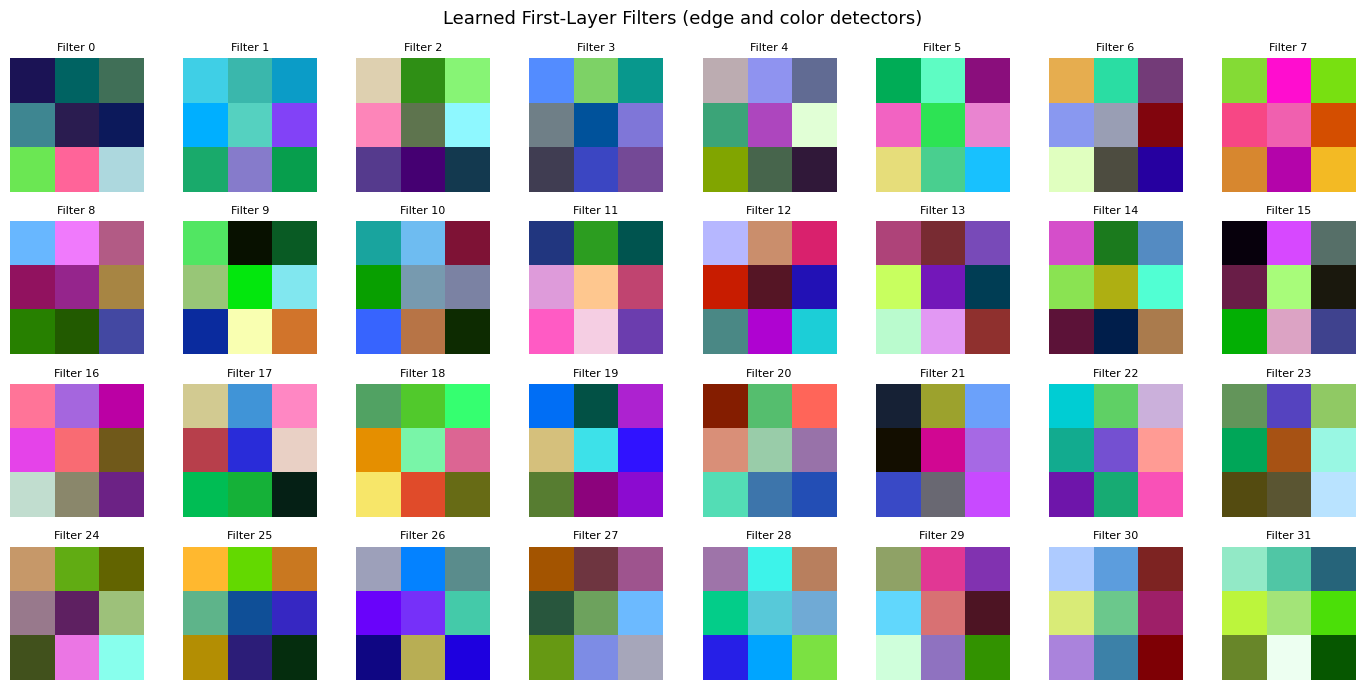

In [13]:
filters, biases = model_cnn.layers[0].get_weights()
print(f"First layer filters shape: {filters.shape}")  # (3, 3, 3, 32)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    # Normalize each filter to [0, 1] for display
    f = filters[:, :, :, i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f)
    ax.axis('off')
    ax.set_title(f'Filter {i}', fontsize=8)
plt.suptitle('Learned First-Layer Filters (edge and color detectors)', fontsize=13)
plt.tight_layout()
plt.show()

Early layers learn edges and color gradients. Deeper layers (not easily visualized) combine those into shapes and objects. This hierarchical feature extraction is why CNNs are the default for image tasks — from CIFAR-10 to medical imaging.

**Up next: RNNs for sequential data — because not all data is images.**